In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

Preliminary:

- Using make_classification from sklearn, generate a binary dataset with 100k data points and with 30 features.


In [4]:
X, y = make_classification(n_samples=100000,
                        n_features= 30,
                        n_informative=10,
                        flip_y=0.2 )

1. Plot the validation curve, using all CPUs, with 5 folds. The goal is to focus again on max_depth between 1 and 20.
   You may need to increase the window (example: between 1 and 50 ) if you notice that other values of max_depth could have returned better results. This may take a few minutes.

We do not expect you to implement all the plot from scratch, you should leverage the code here:

The plot should look like this:

![logo_ex5q1](./w2_day5_ex5_q1.png)

The interpretation is that from max_depth=10, the train score keeps increasing but the test score (or validation score) reaches a plateau. It means that choosing max_depth = 20 may lead to having an overfitted model.

> Note: Given the computation time, it is not possible to plot the validation curve for all parameters. It is useful to plot it for the parameters that control the overfitting the most.

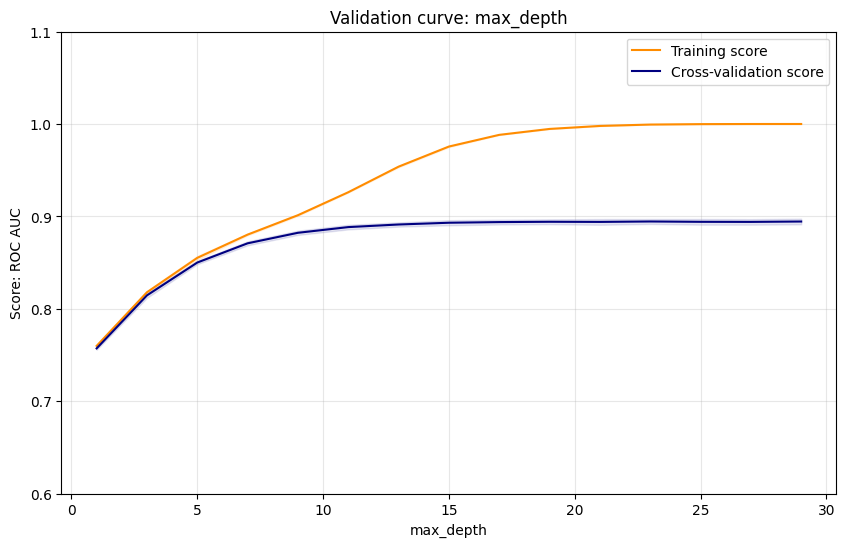

In [17]:
param_range = np.arange(1, 31, 2)

# 2. Use RandomForestClassifier instead of DecisionTreeClassifier
# Note: n_jobs=-1 is crucial here as Random Forests take longer to train
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42), 
    X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1 
)

# 3. Calculate means and stds (Your code was perfect here)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Plot (Your code was perfect here too)
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training score", color="darkorange")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="darkorange")
plt.plot(param_range, test_mean, label="Cross-validation score", color="navy")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="navy")

plt.title("Validation curve: max_depth")
plt.xlabel("max_depth")
plt.ylabel("Score: ROC AUC")
plt.ylim(0.6, 1.1)
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

In [12]:
train_scores, test_scores

(array([[0.57961039, 0.58191327, 0.58157201, 0.58287862, 0.58670182],
        [0.72097629, 0.72148524, 0.72175678, 0.71803937, 0.72469874],
        [0.79540774, 0.79915129, 0.80071078, 0.79750963, 0.80207761],
        [0.84299621, 0.84349622, 0.84420154, 0.84414745, 0.8458225 ],
        [0.87420146, 0.87542949, 0.87527541, 0.87398106, 0.87678287],
        [0.90200427, 0.90304805, 0.9034419 , 0.90225921, 0.90371127],
        [0.92845758, 0.92872931, 0.92981985, 0.92710677, 0.92975111],
        [0.94955533, 0.94929458, 0.95113027, 0.94931601, 0.95173532],
        [0.96440518, 0.96511535, 0.96629031, 0.96666452, 0.96732549],
        [0.97567164, 0.97606106, 0.9774676 , 0.97785995, 0.97778587],
        [0.98335403, 0.9843065 , 0.98544992, 0.98555722, 0.98539874],
        [0.98873083, 0.98990592, 0.99054833, 0.99087156, 0.99093998],
        [0.99255087, 0.99366412, 0.99392496, 0.9947422 , 0.99468796],
        [0.99504928, 0.99592263, 0.99612357, 0.99719558, 0.99676677],
        [0.99676348,

2. Let us assume the gridsearch returned `clf = RandomForestClassifier(max_depth=12)`. Let's check if the model underfits, overfits, or fits correctly. Plot the learning curve. These two resources will help you a lot to understand how to analyze the learning curves and how to plot them:

- **Re-use the function in the second resource**, change the cross-validation to a classic 10-folds, run the learning curve data computation on all CPUs and plot the three plots as shown below.

![logo_ex5q2](./w2_day5_ex5_q2.png)

- **Note Plot Learning Curves**: The learning curve is detailed in the first resource.

- **Note Plot Scalability of the model**: This plot shows the relationship between the time to train the model and the number of rows in the data. In that case the relationship is linear.

- **Note Performance of the model**: This plot shows whether it is worth increasing the training time by adding data to increase the score. It would be worth adding data to increase the score if the curve hasn't reached a plateau yet. In this case, increasing the training time by 10 units increases the score by less than 0.001.


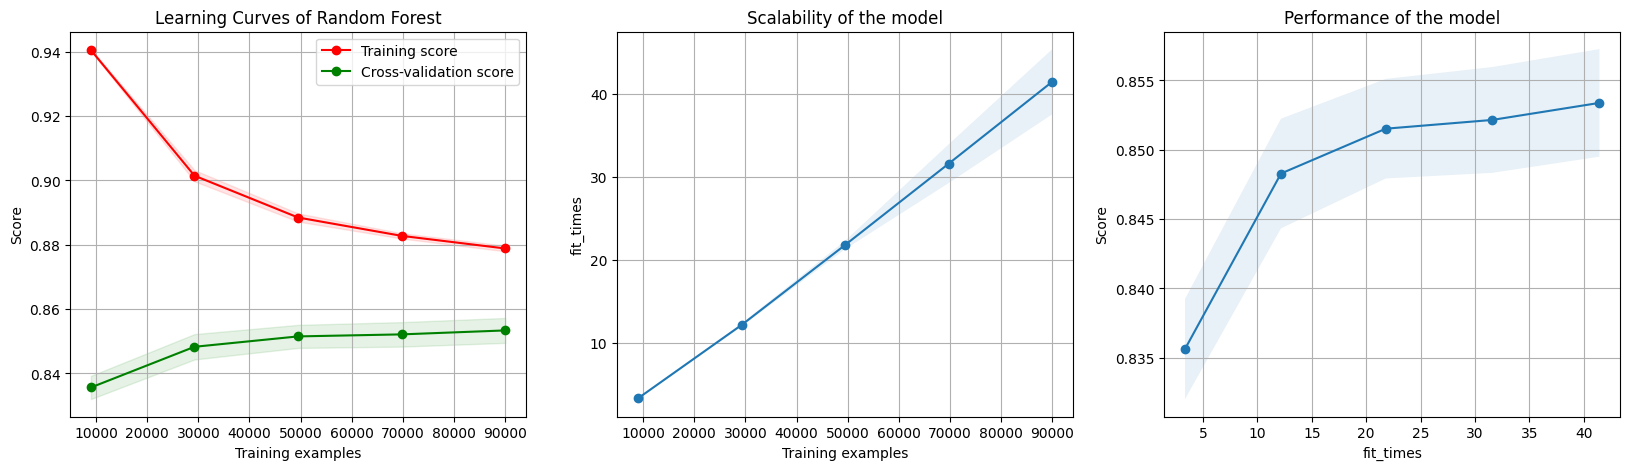

In [10]:
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    # Compute learning curve data
    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes,
                       return_times=True)
    
    # Calculate means and standard deviations
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

# --- Execution ---

# 1. Define the model as instructed
clf = RandomForestClassifier(max_depth=12, random_state=42)

# 2. Call the plotting function
# cv=10 for 10-folds, n_jobs=-1 to use all CPUs
plot_learning_curve(
    estimator=clf, 
    title="Learning Curves of Random Forest", 
    X=X, y=y, 
    cv=10, 
    n_jobs=-1
)

plt.show()